# Chapitres supplémentaires : Méthodes approchées de Chang et Künysky dans le cas 2D

Dans cet exercice, nous allons implémenter les méthodes approchées de Chang et Kunyansky pour la reconstruction en Tomographie par Émission de Pét (PET).

Les versions 2D de ces méthodes ont été abordées dans les cours principaux, et c'est ce que nous allons implémenter. Les reconstructions en dimension 3 sont plus coûteuses en termes de programmation et de quantité de calculs. D'un autre côté, en dimension 3, il y a plus de données, ce qui permet non seulement des reconstructions par tranches, mais aussi d'utiliser les corrélations entre les signaux dans différentes tranches. Comme le montre la pratique, l'utilisation de ces corrélations permet de réduire considérablement le niveau de bruit dans les reconstructions.

Il convient de noter que ces méthodes sont généralement utilisées pour la Tomographie par Émission Single Photon (SPECT), et non pour la PET, où la transformation pondérée est beaucoup plus simple. Nous considérons la PET dans cet exercice uniquement parce que les expériences numériques correspondantes sont beaucoup plus faciles à modéliser.

### Importation des bibliothèques et des fonctions externes

In [ ]:
# import libraries

import numpy as np
import matplotlib.pyplot as plt
import tomopy
import time
from skimage.transform import iradon

import os
import numba as nb

In [ ]:
@nb.njit
def sidon_line_projector(image, phi, shift, radius=1.0):
    """
        Sidon line projector - fast and exact execution algorithm
        for the ray transform along the line

        The code is not yet optimized - works not really fast 
    """
    
    c = np.cos(phi)
    s = np.sin(phi)
    R = radius
    sh = shift
    
    if (sh > R*np.sqrt(2)):
        return 0
    
    # get image size, pixel size
    npixels = image.shape[0]
    dx = 2*R / npixels # pixel's side length 
    
    # set the geometry of the line
    line_center = np.array([[sh * c], [sh * s]])
    direction = np.array([[-s], [c]])
    
    # 1. find intersections of the line with borders [-radius,radius]x[-radius, radius]
    n_intersect_pts = 0
    end_pts = np.zeros((2,2))
    
    # bottom border
    if (np.abs((sh + R*s)) < np.abs(c)*R):
        end_pts[n_intersect_pts, 0] = (sh + R*s)/c
        end_pts[n_intersect_pts, 1] = -R
        n_intersect_pts += 1 
        
    # right border
    if (np.abs((sh - R*c)) < np.abs(s)*R):
        end_pts[n_intersect_pts, 0] = R
        end_pts[n_intersect_pts, 1] = (sh - R*c)/s
        n_intersect_pts += 1 
            
            
    # top border
    if (np.abs((sh - R*s)) < np.abs(c)*R and n_intersect_pts < 2):
        end_pts[n_intersect_pts, 0] = (sh - R*s)/c
        end_pts[n_intersect_pts, 1] = R
        n_intersect_pts += 1 
            
    # left border
    if (np.abs((sh + R*c)) < np.abs(s)*R and n_intersect_pts < 2):
        end_pts[n_intersect_pts, 0] = -R
        end_pts[n_intersect_pts, 1] = (sh + R*c)/s
        n_intersect_pts += 1
            
    #assert (n_intersect_pts == 2), f"Failed to find 2 intersections. Line parameters: shift={sh}, phi={phi}, n_intersect={n_intersect_pts}"
    
    
    # check if points are not ordered according the direction - flip rows
    if (np.dot(end_pts[1, :] - end_pts[0, :], direction) < 0):
        tmp = end_pts[1].copy()
        end_pts[1] = end_pts[0]
        end_pts[0] = tmp
        #end_pts = np.flipud(end_pts, axis=0)
        #end_pts[[0, 1], :] = end_pts[[1, 0], :] 
    
        
    # 2.1 compute intersections x-axes
    x_max = np.max(end_pts[:, 0])
    x_min = np.min(end_pts[:, 0])
    dir_x = end_pts[1, 0] - end_pts[0, 0]
    
    x_axes = np.linspace(-R, R, npixels + 1)[1 : -1]
    x_coords_intersect = x_axes[(x_axes > x_min)*(x_axes < x_max)]
    x_pts_intersect = []
    for x in x_coords_intersect:
        alpha = (x - end_pts[0, 0])  / dir_x
        #assert ((alpha > 0.0) and (alpha < 1.0)), f"Failure to find intersection with line x={x}."
        y = end_pts[0, 1] * (1.0 - alpha) + end_pts[1, 1] * alpha
        x_pts_intersect.append([x, y, alpha]) 
    
    # 2.2 compute intersections y-axes
    y_max = np.max(end_pts[:, 1])
    y_min = np.min(end_pts[:, 1])
    dir_y = (end_pts[1, 1] - end_pts[0, 1])
    
    y_axes = np.linspace(-R, R, npixels + 1)[1 : -1]
    y_coords_intersect = y_axes[(y_axes > y_min)*(y_axes < y_max)]
    y_pts_intersect = []
    for y in y_coords_intersect:
        alpha = (y - end_pts[0, 1])  / dir_y
        #assert ((alpha > 0.0) & (alpha < 1.0))
        x = end_pts[0, 0] * (1.0 - alpha) + end_pts[1, 0] * alpha
        y_pts_intersect.append([x, y, alpha])
    
    # 3. merge ordered arrays of intersection points into one array of ordered intersections points
    #    increasing ordering ordering - column alpha
    
    # order both arrays x_pts_intersect, y_pts_intersect in increasing length with order
    if ((end_pts[1, 0] - end_pts[0, 0]) < 0.0):
        x_pts_intersect.reverse()
        
    if ((end_pts[1, 1] - end_pts[0, 1]) < 0.0):
        y_pts_intersect.reverse()
    
    len_x_intersect = len(x_pts_intersect)
    len_y_intersect = len(y_pts_intersect)
    ind_x = 0
    ind_y = 0
    pts_intersect = []
    
    # Numba feature (list.insert is not implemented in Numba yet)
    pts_intersect.append([end_pts[0, 0], end_pts[0, 1],  0])
    
    while (ind_x < len_x_intersect and ind_y < len_y_intersect):
            
        if (x_pts_intersect[ind_x][-1] < y_pts_intersect[ind_y][-1]):
            pts_intersect.append(x_pts_intersect[ind_x])
            ind_x += 1
            continue
            
        if (x_pts_intersect[ind_x][-1] > y_pts_intersect[ind_y][-1]):
            pts_intersect.append(y_pts_intersect[ind_y])
            ind_y += 1
            continue
                
        if (x_pts_intersect[ind_x][-1] == y_pts_intersect[ind_y][-1]):
            pts_intersect.append(x_pts_intersect[ind_x])
            ind_x += 1
            ind_y += 1
            # continue 

    if (ind_x == len_x_intersect):
            
            assert ind_y < len_y_intersect, "Failed to attach the rest of ordered y-array"
            
            for ind in range(ind_y, len_y_intersect):
                pts_intersect.append(y_pts_intersect[ind])
            
    if (ind_y == len_y_intersect):
            assert ind_x < len_x_intersect, "Failed to attach the rest of ordered x-array"
            
            for ind in range(ind_x, len_x_intersect):
                pts_intersect.append(x_pts_intersect[ind])
                
            
    # add last point
    pts_intersect.append([end_pts[1, 0], end_pts[1, 1],  1])
    
    # 4. compute the value of the line integral
    ray_int_value = 0.0
    len_intersection = np.linalg.norm(end_pts[0] - end_pts[1])
    
    for ind in range(len(pts_intersect)-1):
        pix_len = (pts_intersect[ind + 1][2] - pts_intersect[ind][2])
        
        # get indicies of middle points
        mid_x = (pts_intersect[ind + 1][0] + pts_intersect[ind][0]) * 0.5
        mid_y = (pts_intersect[ind + 1][1] + pts_intersect[ind][1]) * 0.5        
        ind_x = int((mid_x + R) / dx) 
        ind_y = npixels - 1 - int((mid_y + R) / dx)
        
        im_val = 0.0
        if (ind_x >= 0 and ind_x < npixels and ind_y >= 0 and ind_y < npixels):
            im_val = image[ind_y, ind_x]
        
        ray_int_value += pix_len * im_val
        
    # computation is over
    return ray_int_value * len_intersection


@nb.njit(parallel=True)
def radon2d_sidon(image, ntheta, nshift, radius=1.0):
    
    # image size
    npixels = image.shape[0]
    dx = 2.0*radius / npixels
    shifts = np.linspace(-radius + dx/2, radius-dx/2, nshift)
    theta = np.linspace(0, 2*np.pi-2*np.pi/ntheta, ntheta)
    
    # compute projections 
    proj = np.zeros((ntheta, nshift))
    for i_theta in range(ntheta):
        for i_shift in range(nshift):
            proj[i_theta][i_shift] = sidon_line_projector(image, theta[i_theta], 
                                                          shifts[i_shift], radius)    
    return proj


def adjradon2d(proj, npixels, radius=1.0, leftbnd=0., rightbnd=0.):
    (nphi, nshift) = proj.shape
    
    # set grid in Radon space
    # angles 'phi' on [0, 2*pi)
    dphi   = 2 * np.pi / nphi;
    dshift = 2 * radius / nshift
    dx = 2 * radius / npixels
    phi_proj = np.arange(nphi) * dphi
    shifts_proj = -radius + dshift/2 + np.arange(nshift) * dshift

    # create grid on square [-radius,radius]^2
    lin = -radius + dx/2 + np.arange(npixels) * dx
    XX,YY = np.meshgrid(lin, -lin)
    XX = np.reshape(XX, (1, npixels**2)) #reshape the domain in 2 long arrays (x,y) 
    YY = np.reshape(YY, (1, npixels**2))
    points = np.concatenate((XX, YY)) # size 2 x npixels^2

    # main computation --------------------------------------
    adjradon = np.zeros((1, npixels**2))    

    # integral over sphere for each x 
    for i_phi in range(nphi):
        
        phi = phi_proj[i_phi]
        theta_direction = np.array([np.cos(phi), np.sin(phi)])

        # shifts in the integrand for fixed - phi
        shifts_eval = np.dot(np.transpose(points), theta_direction)

        # values of the Radon transforms for shifts_eval 
        vals_interpolated = np.interp(shifts_eval, shifts_proj, proj[i_phi, :],  left=leftbnd, right=rightbnd)

        # sum all terms for fixed phi
        adjradon += vals_interpolated * dphi

    adjradon = np.reshape(adjradon, (npixels, npixels));
    return adjradon



### Rappel de théorie

Dans le PET/SPECT, la transformation de Radon est pondérée et est définie par la formule suivante :

\begin{equation}
    R_Wf(s,\theta) = \int\limits_{x\theta=s}f(x)W(x,\theta) \, dx,
\end{equation}
où $f(x)$ est la densité de l'isotope et $W(x,\theta)$ est le poids associé à l'atténuation du rayonnement.
Dans le PET/SPECT, le poids $W$ est défini par la formule
\begin{align}
    W_a(x,\theta) &= e^{-Ra(x\theta, \theta)} \text{ (PET)},\\
    W_a(x,\theta) &= e^{-Da(x,\theta)}, Da(x,\theta) = \int\limits_{0}^{+\infty}a(x + t\theta^\perp)\, dt \text{ (SPECT)},
\end{align}
où $a$ est la carte d'atténuation du rayonnement.

### Création de fantôme

Nous testerons les exemples sur le modèle des fantômes Shepp-Logan. Étant donné que nous effectuerons le test dans le contexte du PET, nous devons créer deux objets pour les calculs :

1. La carte d'émission (où se trouve la substance active) - fantôme Shepp-Logan "avec une tumeur ajoutée"
2. La carte d'atténuation du rayonnement (comment la matière atténue le signal sortant) - fantôme Shepp-Logan sans "tumeur"

Pour que la simulation soit plus proche de la réalité, il est nécessaire de normaliser la carte d'atténuation car elle entre non-linéairement dans la transformation pondérée de Radon correspondante. Dans le PET, l'énergie des photons est de 511 KeV, ce qui correspond à un coefficient d'atténuation linéique $\mu_w=9.687E-02[cm^{-1}]$ (coefficient d'absorption de l'eau). Le coefficient d'atténuation pour les os (crâne) à cette énergie est d'environ $\mu_b=9.022E-02[cm^{-1}]$. Des données tabulaires plus précises peuvent être trouvées sur le site [NIST](https://physics.nist.gov/PhysRefData/XrayMassCoef/tab4.html).

Ci-dessous, nous présentons le code qui effectue la normalisation du fantôme. La grandeur caractéristique déterminant l'"atténuation du signal" est les longueurs optiques $l_x = \int_{Ox}\mu(z)\, dz$, $l_y = \int_{Oy}\mu(z)\, dz$ le long des axes principaux $Ox$, $Oy$. Cela signifie que le signal PET est atténué de $e^{-l_x}$, $e^{-l_y}$ fois le long de ces axes respectivement.

In [ ]:
N = 128
D = 30 # side length of the domain in [cm]

emmap = np.reshape(tomopy.misc.phantom.shepp2d(N), (N, N)) # Shepp-Logan Phantom
attmap = np.reshape(tomopy.misc.phantom.shepp2d(N), (N, N)) # Shepp-Logan Phantom

# plot 2D-phantoms
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axs[0].imshow(emmap)
axs[0].set_title('Emission map')
axs[1].imshow(attmap)
axs[1].set_title('Attenuation map')
plt.show()

In [ ]:
# before normalization - characteristic values 

print("Before normalization")
print("Value at cranium:", attmap[5, 64])
print("Value at brain tissue (water):", attmap[20, 64])
print("Value at lobe tissue:", attmap[40, 64])
print("Value at void space (outsize / inside):", attmap[60, 40])

# normalization to energy-attenation

attmap[attmap == attmap[5, 64]] = 9.022e-02
attmap[attmap == attmap[20, 64]] = 9.687e-02
attmap[attmap == attmap[40, 64]] = 9.695e-02
attmap[attmap == 0.] = 0.
attmap[attmap >  0.1] = 0. # cut off interpolation values
 
# after normalization - characteristic values 

print("Before normalization")
print("Value at cranium:", attmap[5, 64])
print("Value at brain tissue (water):", attmap[20, 64])
print("Value at lobe tissue:", attmap[40, 64])
print("Value at void space (outsize / inside):", attmap[60, 40])


# optical axes

print("")
print("Optical length along x-asis:", attmap[64, :].sum() * D / N)
print("Optical length along y-asis:", attmap[:, 64].sum() * D / N)

plt.imshow(attmap)
plt.title('Attenuation map - normalized')
plt.show()

Notez que, après la normalisation, le contraste sur la carte d'absorption est presque inexistant - en effet, à cette énergie des photons, les coefficients d'atténuation pour les os et les tissus mous sont pratiquement identiques. Cela facilite grandement la construction de cartes d'atténuation en pratique, par exemple à partir d'"images complètement étrangères", comme celles provenant de l'IRM (en IRM, on mesure la "densité protonique", qui est pratiquement sans lien avec l'atténuation linéaire des rayons X ; mais en utilisant une simple correspondance sur les images - tissus mous -> eau, solides -> os, on peut obtenir une carte d'atténuation pour la tomodensitométrie sans scanner préalable).

In [ ]:
# generation of attenuated sinogram

#attmap /= 5.
attcorrection = np.exp(-radon2d_sidon(attmap, 256, 256, D/2.0))
projections = radon2d_sidon(emmap, 256, 256, D/2.0)
petsinogram = attcorrection * projections

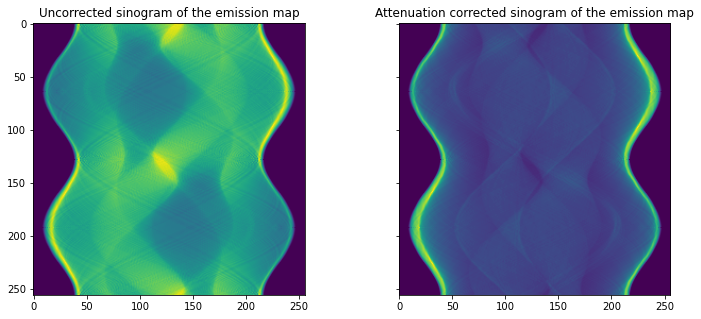

In [253]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot1 = axs[0].imshow(projections)
axs[0].set_title('Uncorrected sinogram of the emission map')
plot2 = axs[1].imshow(petsinogram)
axs[1].set_title('Attenuation corrected sinogram of the emission map')
plt.show()

### Méthode de Chang

Pour commencer, construisons la reconstruction complètement sans tenir compte de l'atténuation du signal, en appliquant simplement l'opérateur $R^{-1}$ à $R_Wf$.

In [254]:
petrec = iradon(petsinogram[0:128].transpose())
rec = iradon(projections[0:128].transpose())

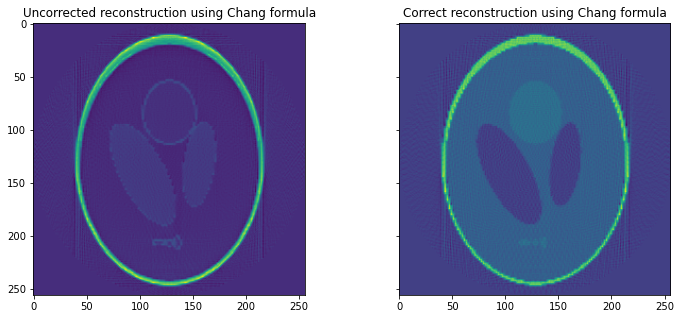

In [255]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

plot1 = axs[0].imshow(petrec)
axs[0].set_title('Uncorrected reconstruction using Chang formula')
plot2 = axs[1].imshow(rec)
axs[1].set_title('Correct reconstruction using Chang formula')
plt.show()


Il reste à calculer la correction $w_0$. Dans le cas de la PET, cela se fait facilement en utilisant la transformée de Radon adjointe.

In [256]:
w0 = adjradon2d(attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)

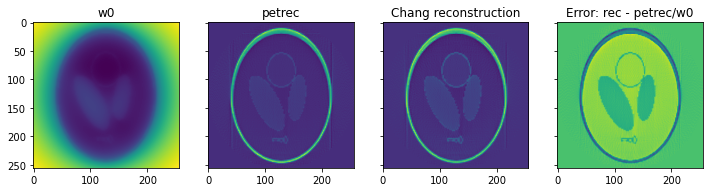

Errors: |rec-petrec| (ignoring attenuation): 1196.2041776910055 |rec-petrec/w0| (Chang): 1789.296526373791


In [257]:
fig, axs = plt.subplots(1, 4, figsize=(12, 5), sharey=True)

plot1 = axs[0].imshow(w0)
axs[0].set_title('w0')
plot2 = axs[1].imshow(petrec)
axs[1].set_title('petrec')
plot3 = axs[2].imshow(petrec/w0)
axs[2].set_title('Chang reconstruction')
plot4 = axs[3].imshow(rec-petrec/w0)
axs[3].set_title('Error: rec - petrec/w0')
plt.show()

recchang = petrec/w0
err = np.linalg.norm(rec-petrec)
errchang = np.linalg.norm(rec - petrec/w0)

print("Errors: |rec-petrec| (ignoring attenuation):", err, "|rec-petrec/w0| (Chang):", errchang)

### Méthode de Kunyansky

Dans cette tâche, nous allons essayer de prendre en compte plus de fréquences angulaires et obtenir des reconstructions meilleures que celles du méthode de Chang.
D'après la théorie, vous savez que la méthode fonctionnera si 
\begin{equation}
    \sigma_{W,D,m} = \sum\limits_{k=1}^{m} \sup_{x\in D} |w_{2k} / w_0| < 1.
\end{equation}

Pour implémenter la méthode, nous devons mettre en œuvre deux nouvelles fonctions :

 1. Le calcul des fréquences $w_{k}$
 2. L'application de l'opérateur $Q_{W,D,m}$

Comme d'habitude, nous voulons que nos calculs soient "rapides", donc il faut chercher des méthodes de calcul plus rapides, par exemple, plutôt que de calculer point par point dans des boucles.

*Indice 1 :* regardez comment nous avons calculé $w_0$ dans le paragraphe précédent. Est-il possible de faire des calculs similaires ?
*Indice 2 :* d'après les notes de cours, vous savez que l'opérateur $Q_{W,D,m}$ peut être exprimé à l'aide de convolutions. Existe-t-il un moyen de calculer rapidement une convolution ?

In [258]:
def weightFreqSine(degree, proj, npixels, radius=1.0, leftbnd=0., rightbnd=0.):
    (nphi, nshift) = proj.shape
    
    # set grid in Radon space
    # angles 'phi' on [0, 2*pi)
    dphi   = 2 * np.pi / nphi;
    dshift = 2 * radius / nshift
    dx = 2 * radius / npixels
    phi_proj = np.arange(nphi) * dphi
    shifts_proj = -radius + dshift/2 + np.arange(nshift) * dshift

    # create grid on square [-radius,radius]^2
    lin = -radius + dx/2 + np.arange(npixels) * dx
    XX,YY = np.meshgrid(lin, -lin)
    XX = np.reshape(XX, (1, npixels**2)) #reshape the domain in 2 long arrays (x,y) 
    YY = np.reshape(YY, (1, npixels**2))
    points = np.concatenate((XX, YY)) # size 2 x npixels^2

    # main computation --------------------------------------
    adjradon = np.zeros((1, npixels**2))    

    # integral over sphere for each x 
    for i_phi in range(nphi):
        
        phi = phi_proj[i_phi]
        theta_direction = np.array([np.cos(phi), np.sin(phi)])

        # shifts in the integrand for fixed - phi
        shifts_eval = np.dot(np.transpose(points), theta_direction)

        # values of the Radon transforms for shifts_eval 
        vals_interpolated = np.interp(shifts_eval, shifts_proj, proj[i_phi, :],  left=leftbnd, right=rightbnd)

        # sum all terms for fixed phi
        adjradon += np.sin(degree * phi) * vals_interpolated * dphi

    adjradon = np.reshape(adjradon, (npixels, npixels));
    return adjradon

def weightFreqCosine(degree, proj, npixels, radius=1.0, leftbnd=0., rightbnd=0.):
    (nphi, nshift) = proj.shape
    
    # set grid in Radon space
    # angles 'phi' on [0, 2*pi)
    dphi   = 2 * np.pi / nphi;
    dshift = 2 * radius / nshift
    dx = 2 * radius / npixels
    phi_proj = np.arange(nphi) * dphi
    shifts_proj = -radius + dshift/2 + np.arange(nshift) * dshift

    # create grid on square [-radius,radius]^2
    lin = -radius + dx/2 + np.arange(npixels) * dx
    XX,YY = np.meshgrid(lin, -lin)
    XX = np.reshape(XX, (1, npixels**2)) #reshape the domain in 2 long arrays (x,y) 
    YY = np.reshape(YY, (1, npixels**2))
    points = np.concatenate((XX, YY)) # size 2 x npixels^2

    # main computation --------------------------------------
    adjradon = np.zeros((1, npixels**2))    

    # integral over sphere for each x 
    for i_phi in range(nphi):
        
        phi = phi_proj[i_phi]
        theta_direction = np.array([np.cos(phi), np.sin(phi)])

        # shifts in the integrand for fixed - phi
        shifts_eval = np.dot(np.transpose(points), theta_direction)

        # values of the Radon transforms for shifts_eval 
        vals_interpolated = np.interp(shifts_eval, shifts_proj, proj[i_phi, :],  left=leftbnd, right=rightbnd)

        # sum all terms for fixed phi
        adjradon += np.cos(degree * phi) * vals_interpolated * dphi

    adjradon = np.reshape(adjradon, (npixels, npixels));
    return adjradon



In [ ]:
w0 = weightFreqCosine(0., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi) # recompute zero frequency

w2_s = weightFreqSine(-2., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w2_c = weightFreqCosine(-2., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w2 = (w2_c + 1j * w2_s)

wm2_s = weightFreqSine(2., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm2_c = weightFreqCosine(2., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm2 = wm2_c + 1j * wm2_s

w4_c = weightFreqSine(-4., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w4_s = weightFreqCosine(-4., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w4 = w4_c + 1j * w4_s

wm4_c = weightFreqCosine(4., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm4_s = weightFreqSine(4., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm4 = wm4_c + 1j * wm4_s

w6_c = weightFreqSine(-6., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w6_s = weightFreqCosine(-6., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w6 = w6_c + 1j * w6_s

wm6_c = weightFreqCosine(6., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm6_s = weightFreqSine(6., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm6 = wm6_c + 1j * wm6_s

w8_c = weightFreqSine(-8., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w8_s = weightFreqCosine(-8., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
w8 = w8_c + 1j * w8_s

wm8_c = weightFreqCosine(8., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm8_s = weightFreqSine(8., attcorrection, 256, D/2., leftbnd=1.0, rightbnd=1.0) / (2*np.pi)
wm8 = wm8_c + 1j * wm8_s

# Note that in parametrisations R_W, P_~W - frequencies of W are different: to say, let w_{2k} be the frequency
# in R_W, then in P_W the frequency is (-1)^k w_{2k}

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(12, 5), sharey=True)

plot1 = axs[0].imshow(np.abs(w2/w0))
axs[0].set_title('abs w_2/w_0')
plot2 = axs[1].imshow(np.abs(wm2/w0))
axs[1].set_title('abs w_{-2}/w_0')
plot3 = axs[2].imshow(np.abs(w6/w0))
axs[2].set_title('abs w_6/w_0')
plot4 = axs[3].imshow(np.abs(wm6/w0))
axs[3].set_title('abs w_{-6}/w_0')
plt.show()

In [ ]:
# example of sigma 

sigma2 = np.abs(w2/w0).max() + np.abs(wm2/w0).max()
sigma4 = sigma2 + np.abs(w4/w0).max() + np.abs(wm4/w0).max()
sigma6 = sigma4 + np.abs(w6/w0).max() + np.abs(wm6/w0).max()

print(sigma2, sigma4, sigma6)

In [262]:
# assemble frequencies for f2

nyq = (256 / D) # Nyquist frequency

freqs = np.linspace(-nyq / 2., nyq / 2., 256, endpoint = False)
Xi_x, Xi_y = np.meshgrid(freqs, -freqs)

xi = Xi_x + 1j * Xi_y
xi_bar = Xi_x - 1j * Xi_y

qwd2 = np.divide(xi, xi_bar, out=np.zeros_like(xi_bar), where=xi_bar!=0.)
qwd2m = np.divide(xi_bar, xi, out=np.zeros_like(xi), where=xi!=0)

qwd4 = np.divide(xi, xi_bar, out=np.zeros_like(xi_bar), where=xi_bar!=0.)**2
qwd4m = np.divide(xi_bar, xi, out=np.zeros_like(xi), where=xi!=0.)**2

qwd6 = np.divide(xi, xi_bar, out=np.zeros_like(xi_bar), where=xi_bar!=0.)**3
qwd6m = np.divide(xi_bar, xi, out=np.zeros_like(xi), where=xi!=0.)**3

qwd8 = np.divide(xi, xi_bar, out=np.zeros_like(xi_bar), where=xi_bar!=0.)**4
qwd8m = np.divide(xi_bar, xi, out=np.zeros_like(xi), where=xi!=0.)**4


In [263]:
# assemble mask - unit ball

lin = np.linspace(-1., 1., 256)
XX, YY = np.meshgrid(lin, lin)

mask = np.ones_like(XX)
mask[(XX**2 + YY**2) > 1.0] = 0.

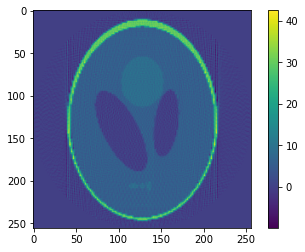

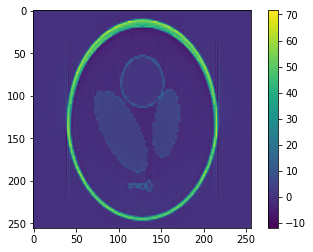

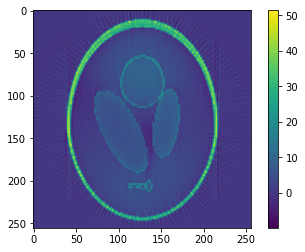

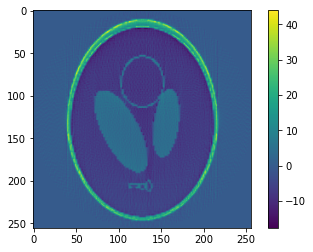

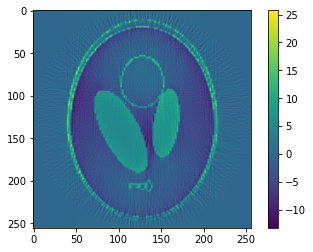

0.9843358986794237 0.5499406342226338


In [270]:
# iterations of Kunyansky's algorithm

niter = 100

curr = petrec
jacobian_ft = (1 / nyq)**2. # jacobian for 2D forward fourier transform
jacobian_ift = (nyq / 256)**2.

full_jacobian = jacobian_ft * jacobian_ift * (256)**2 # jacobian concerning properties of DFT, iDFT

for _ in range(niter):
    update = np.real(np.fft.ifft2(np.fft.fft2(curr * mask * w2/w0) * np.fft.fftshift(qwd2)
                                  + np.fft.fft2(curr * mask * wm2/w0) * np.fft.fftshift(qwd2m) 
                                  #+ np.fft.fft2(curr * mask * w4/w0) * np.fft.fftshift(qwd4)
                                  #+ np.fft.fft2(curr * mask * wm4/w0) * np.fft.fftshift(qwd4m) 
                                  #+ np.fft.fft2(curr * mask * w6/w0) * np.fft.fftshift(qwd6) 
                                  #+ np.fft.fft2(curr * mask * wm6/w0) * np.fft.fftshift(qwd6m)
                                  #+ np.fft.fft2(curr * mask * w8/w0) * np.fft.fftshift(qwd8) 
                                  #+ np.fft.fft2(curr * mask * wm8/w0) * np.fft.fftshift(qwd8m)
                                 )) * full_jacobian
    curr = petrec - update

reckunyansky = curr / w0

plt.imshow(rec)
plt.colorbar()
plt.show()

plt.imshow(recchang)
plt.colorbar()
plt.show()

plt.imshow(reckunyansky)
plt.colorbar()
plt.show()


plt.imshow(recchang - rec)
plt.colorbar()
plt.show()

plt.imshow(reckunyansky - rec)
plt.colorbar()
plt.show()


print(np.linalg.norm(rec - recchang)/np.linalg.norm(rec), np.linalg.norm(rec - reckunyansky)/np.linalg.norm(rec))